# 03 — Cross-Sectional Analysis

**研究問題**：哪類調入股的效應最強？  
**被解釋變數**：`CAR_ann_to_eff`（公告日 → 生效日市場調整累積報酬）  
**解釋變數**：`log_market_cap`、`log_impact_ratio`、`dividend_yield`  

若真實資料未備妥，本 notebook 使用 synthetic data（6 個事件、約 25 個觀測值）。

In [1]:
import sys, logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("../src").resolve()))

from data_fetcher import load_events
from cross_section import (
    build_cross_section_dataset,
    regression_analysis,
    group_analysis,
    fetch_per_multiple,
    fetch_shares_multiple,
)

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(name)s — %(message)s")

PARQUET_PATH = Path("../data/processed/stock_prices.parquet")
EVENTS_PATH  = Path("../data/raw/events.csv")

## 1. 載入或產生資料

In [2]:
USE_SYNTHETIC = not (PARQUET_PATH.exists() and EVENTS_PATH.exists())
print("⚠️  Synthetic mode" if USE_SYNTHETIC else "✅ 載入真實資料")

⚠️  Synthetic mode


In [3]:
# ════════════════════════════════════════════════════════════════
# ⛔  DEPRECATED — 此 cell 產生合成資料，禁止在真實研究中執行
# ════════════════════════════════════════════════════════════════
raise RuntimeError(
    "合成資料已停用。請先建立真實資料 (data/raw/events.csv + "
    "data/processed/stock_prices.parquet) 再執行本 notebook。"
)

# ── 以下為原合成資料程式碼，僅供參考 ──
def _make_synthetic_data():
    """Generate richer synthetic data (6 events, ~25 stock-event pairs)."""
    rng = np.random.default_rng(seed=42)
    trading_days = pd.bdate_range("2021-01-01", "2024-12-31")
    n = len(trading_days)

    # TAIEX
    taiex_rets = rng.normal(0.0003, 0.007, size=n - 1)
    taiex_px   = np.concatenate([[17000.0], 17000.0 * np.cumprod(1 + taiex_rets)])

    # 20 stocks with varying characteristics
    sids = [f"S{i:03d}" for i in range(1, 21)]
    # Vary volatility to simulate large-cap (low vol) vs small-cap (high vol)
    vol_map  = {sid: 0.008 + 0.016 * i / 20 for i, sid in enumerate(sids)}
    base_rets = {sid: rng.normal(0.0002, vol_map[sid], size=n - 1) for sid in sids}

    raw_events = [
        dict(id=1,  ann="2022-03-16", eff="2022-03-23", added=["S001","S002","S003","S004"], removed=["S005"]),
        dict(id=2,  ann="2022-06-15", eff="2022-06-22", added=["S006","S007","S008"],       removed=["S009","S010"]),
        dict(id=3,  ann="2022-09-14", eff="2022-09-21", added=["S011","S012"],               removed=["S001"]),
        dict(id=4,  ann="2022-12-14", eff="2022-12-21", added=["S013","S014","S015","S016"],removed=["S006"]),
        dict(id=5,  ann="2023-03-15", eff="2023-03-22", added=["S017","S018"],               removed=["S012","S013"]),
        dict(id=6,  ann="2023-06-14", eff="2023-06-21", added=["S019","S020","S003"],        removed=["S004"]),
    ]

    # Inject announcement-day shocks (scaled by stock index → smaller stocks get larger shocks)
    shock_profile = {0: +0.018, 1: +0.012, 2: +0.008, 3: +0.006, 4: +0.004, 5: +0.003,
                     **{d: -0.002 for d in range(6, 14)}}

    for ev in raw_events:
        ann = pd.Timestamp(ev["ann"])
        t0  = trading_days.get_loc(trading_days[trading_days >= ann][0])
        for sid in ev["added"]:
            # Larger shock for higher-index stocks (proxy for smaller cap)
            scale = 1 + 0.5 * int(sid[1:]) / 20
            for offset, shock in shock_profile.items():
                idx = t0 + offset
                if 0 <= idx < len(base_rets[sid]):
                    base_rets[sid][idx] += shock * scale

    # Prices
    all_px = {"TAIEX": taiex_px}
    for sid in sids:
        all_px[sid] = np.concatenate([[100.0], 100.0 * np.cumprod(1 + base_rets[sid])])

    prices_wide = pd.DataFrame(all_px, index=trading_days)
    prices_wide.index.name = "date"

    # Turnover (price × random daily volume)
    vol_shares = {sid: rng.integers(100_000, 5_000_000, size=n) for sid in sids}
    turnover_wide = pd.DataFrame(
        {sid: prices_wide[sid].values * vol_shares[sid] for sid in sids},
        index=trading_days,
    )
    turnover_wide.index.name = "date"

    # Shares outstanding (proxy — quarterly updates, varies by stock)
    shares_records = []
    quarterly_dates = pd.date_range("2021-01-01", "2024-12-31", freq="QS-MAR")
    for sid in sids:
        # Smaller-index = larger company
        base_shares = 10e9 / (1 + int(sid[1:]) * 0.3)
        for q_date in quarterly_dates:
            shares_records.append({
                "date": q_date, "stock_id": sid,
                "shares_issued": base_shares * rng.uniform(0.99, 1.01),
            })
    shares_df = pd.DataFrame(shares_records).set_index("date").sort_index()

    # PER / dividend_yield (daily, varies gently over time)
    per_records = []
    for sid in sids:
        base_yield = rng.uniform(2.0, 6.0)  # percent
        for day in trading_days:
            per_records.append({
                "date": day, "stock_id": sid,
                "dividend_yield": max(0.5, base_yield + rng.normal(0, 0.3)),
                "PER": rng.uniform(10, 25), "PBR": rng.uniform(1, 5),
            })
    per_df = pd.DataFrame(per_records).set_index("date").sort_index()

    # Events DataFrame
    event_rows = []
    for ev in raw_events:
        n_added = len(ev["added"])
        etf_aum = rng.uniform(4e9, 8e9)
        # Vary target_weight per stock (sum to ≈ 0.15 of ETF)
        weights = rng.dirichlet(np.ones(n_added)) * 0.15
        tw_dict = dict(zip(ev["added"], weights))
        event_rows.append({
            "event_id":          ev["id"],
            "etf_code":          "00919",
            "announcement_date": pd.Timestamp(ev["ann"]),
            "effective_date":    pd.Timestamp(ev["eff"]),
            "added_stocks":      ev["added"],
            "removed_stocks":    ev["removed"],
            "target_weight":     tw_dict,
            "etf_aum":           etf_aum,
        })
    events = pd.DataFrame(event_rows)

    return prices_wide, turnover_wide, shares_df, per_df, events

In [4]:
if USE_SYNTHETIC:
    prices_wide, turnover_wide, shares_df, per_df, events = _make_synthetic_data()

else:
    # ── 真實資料 ──────────────────────────────────────────────────────────────
    long_df = pd.read_parquet(PARQUET_PATH)
    if "date" in long_df.columns:
        long_df = long_df.set_index("date")
    long_df.index = pd.to_datetime(long_df.index)

    prices_wide = (
        long_df.reset_index()
        .pivot(index="date", columns="stock_id", values="close")
        .sort_index()
    )
    prices_wide.columns.name = None

    turnover_wide = (
        long_df.reset_index()
        .pivot(index="date", columns="stock_id", values="turnover")
        .sort_index()
    )
    turnover_wide.columns.name = None

    events = load_events(EVENTS_PATH)

    # Collect all unique stock IDs across all events
    all_sids = sorted(set(
        sid
        for col in ["added_stocks", "removed_stocks"]
        for sids in events[col]
        for sid in sids
    ))
    print(f"{len(all_sids)} unique stocks across all events")

    # Determine date range (add buffer for pre-event window)
    start = (events["announcement_date"].min() - pd.DateOffset(months=4)).strftime("%Y-%m-%d")
    end   = events["effective_date"].max().strftime("%Y-%m-%d")

    print(f"Fetching PER and shares data from {start} to {end} …")
    per_df    = fetch_per_multiple(all_sids, start, end)
    shares_df = fetch_shares_multiple(all_sids, start, end)
    print(f"per_df: {len(per_df)} rows  |  shares_df: {len(shares_df)} rows")

market_returns = prices_wide["TAIEX"].pct_change().rename("market_ret")
print(f"prices_wide: {prices_wide.shape}  |  events: {len(events)} rows")

prices_wide: (1043, 21)  |  events: 6 rows


## 2. 建立橫斷面資料集

In [5]:
cs_df = build_cross_section_dataset(
    events=events,
    prices_wide=prices_wide,
    market_returns=market_returns,
    turnover_wide=turnover_wide,
    shares_df=shares_df,
    per_df=per_df,
    winsorize_impact=True,
    stock_col="added_stocks",
)

print(f"Cross-section dataset: {cs_df.shape}")
cs_df.head()

2026-05-17 18:34:39,086 [INFO] cross_section — Winsorized 2 impact_ratio values (1%/99% quantiles)


Cross-section dataset: (18, 15)


,event_id,etf_code,announcement_date,stock_id,CAR_ann_to_eff,market_cap,avg_volume_60d,dividend_yield,log_market_cap,log_avg_volume,target_weight,etf_aum,impact_ratio,log_impact_ratio,impact_ratio_raw
0,1,00919,2022-03-16,S001,0.040668,7.720090e+11,2.666665e+08,5.978875,27.372262,19.401509,0.020144,7.203688e+09,0.000188,-8.579258,0.000188
1,1,00919,2022-03-16,S002,0.033926,7.560517e+11,3.123456e+08,4.116702,27.351376,19.559621,0.018517,7.203688e+09,0.000176,-8.642594,0.000176
2,1,00919,2022-03-16,S003,0.068674,4.900888e+11,2.166635e+08,6.003597,26.917852,19.193856,0.044329,7.203688e+09,0.000652,-7.336103,0.000652
3,1,00919,2022-03-16,S004,0.040240,5.172973e+11,2.421955e+08,5.159139,26.971884,19.305256,0.067010,7.203688e+09,0.000933,-6.976938,0.000933
4,2,00919,2022-06-15,S006,0.033266,4.888824e+11,3.469841e+08,3.086333,26.915388,19.664789,0.023430,6.527083e+09,0.000313,-8.069879,0.000313


## 3. 分布檢查（在迴歸前必做）

In [6]:
print("=== 摘要統計 ===")
display_cols = ["CAR_ann_to_eff", "market_cap", "avg_volume_60d",
                "dividend_yield", "impact_ratio", "log_impact_ratio"]
cs_df[display_cols].describe().applymap(lambda x: f"{x:.4g}")

=== 摘要統計 ===


/var/folders/rt/cd9crnjx7ll15xvnrmhsnzd80000gn/T/ipykernel_33851/1280435053.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cs_df[display_cols].describe().applymap(lambda x: f"{x:.4g}")


,CAR_ann_to_eff,market_cap,avg_volume_60d,dividend_yield,impact_ratio,log_impact_ratio
count,18,18,18,18,18,18
mean,0.07254,4.082e+11,3.825e+08,4.709,0.0009197,-7.43
std,0.05201,2.106e+11,2.503e+08,1.209,0.0007871,1.093
min,-0.006871,1.001e+11,1.82e+08,2.595,6.789e-05,-9.598
25%,0.0355,2.251e+11,2.585e+08,3.716,0.0003191,-8.051
50%,0.06567,3.418e+11,3.113e+08,4.878,0.0008869,-7.029
75%,0.1177,5.538e+11,3.455e+08,5.749,0.001346,-6.613
max,0.1921,7.72e+11,1.051e+09,6.294,0.003229,-5.736


                  missing  pct
CAR_ann_to_eff          0  0.0
market_cap              0  0.0
avg_volume_60d          0  0.0
dividend_yield          0  0.0
impact_ratio            0  0.0
log_impact_ratio        0  0.0


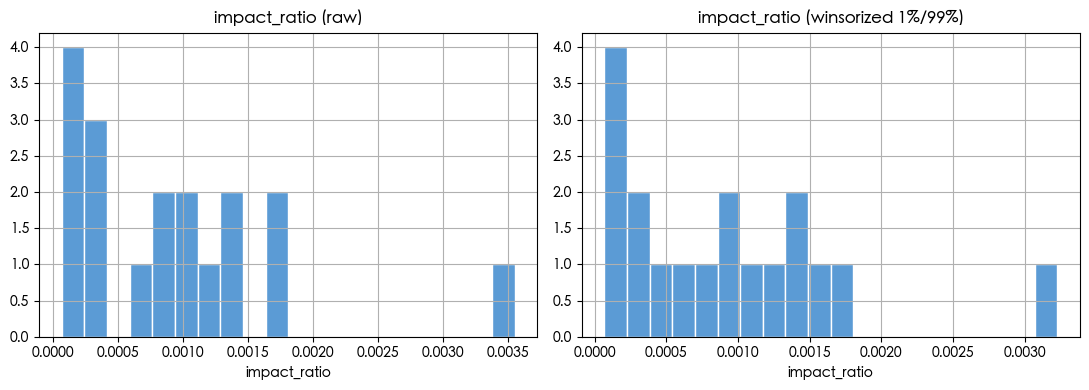

In [7]:
# 顯示完整缺值情況
missing = cs_df[display_cols].isna().sum().rename("missing").to_frame()
missing["pct"] = missing["missing"] / len(cs_df)
print(missing.to_string())

# impact_ratio 分布（winsorize 前後對比）
if "impact_ratio_raw" in cs_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, col, title in zip(axes,
                               ["impact_ratio_raw", "impact_ratio"],
                               ["impact_ratio (raw)", "impact_ratio (winsorized 1%/99%)"]):
        cs_df[col].dropna().hist(ax=ax, bins=20, color="#5b9bd5", edgecolor="white")
        ax.set_title(title); ax.set_xlabel("impact_ratio")
    plt.tight_layout()
    plt.savefig("../output/figures/impact_ratio_distribution.png", dpi=150)
    plt.show()
else:
    cs_df["impact_ratio"].dropna().hist(bins=20, color="#5b9bd5", edgecolor="white",
                                         figsize=(6, 4))
    plt.title("impact_ratio distribution"); plt.tight_layout(); plt.show()

## 4. 迴歸分析

In [8]:
model = regression_analysis(
    cross_section_df=cs_df,
    save_path="../output/tables/regression_results.txt",
)

2026-05-17 18:34:39,501 [INFO] cross_section — Regression table saved → ../output/tables/regression_results.txt


────────────────────────────────────────────────────────────────────
  OLS: CAR (announcement → effective date)
────────────────────────────────────────────────────────────────────
  N = 18   Adj. R² = 0.2514   F-stat p = 0.0035

  ⚠  N = 18 < 20  —  small sample, interpret with caution

  Robust standard errors (HC3)

                     coef  std_err        t    P>|t|  sig
log_market_cap   0.001549 0.028705 0.053979 0.956952     
log_impact_ratio 0.029835 0.011030 2.704832 0.006834  ***
dividend_yield   0.000315 0.009684 0.032482 0.974087     

  Significance: * p<.10  ** p<.05  *** p<.01

  Variance Inflation Factors
        variable  VIF
  log_market_cap 1.27
log_impact_ratio 1.20
  dividend_yield 1.08
  (VIF > 10 → multicollinearity concern)
────────────────────────────────────────────────────────────────────


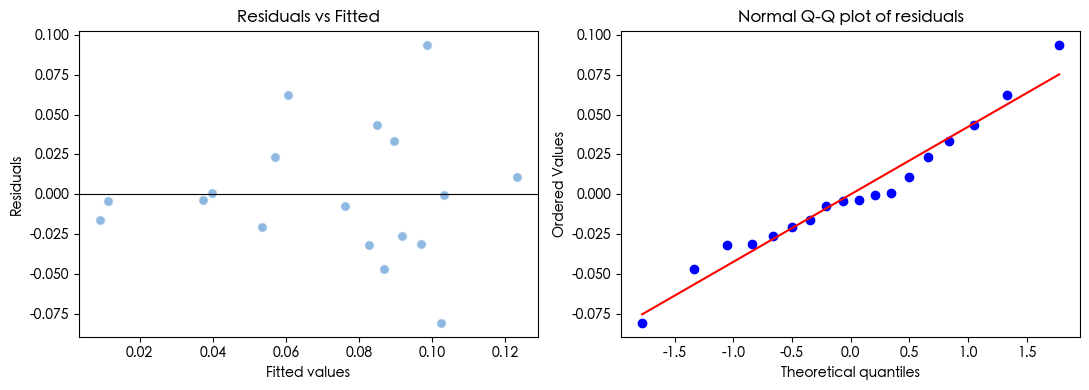

In [9]:
# 迴歸殘差圖（用於確認無明顯異質變異）
resid = model.resid
fitted = model.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(fitted, resid, alpha=0.7, color="#5b9bd5", edgecolors="white", s=50)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xlabel("Fitted values"); axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

from scipy import stats as scipy_stats
scipy_stats.probplot(resid, plot=axes[1])
axes[1].set_title("Normal Q-Q plot of residuals")

plt.tight_layout()
plt.savefig("../output/figures/regression_diagnostics.png", dpi=150)
plt.show()

## 5. 分組分析

In [10]:
summary_impact = group_analysis(
    cross_section_df=cs_df,
    group_var="impact_ratio",
    n_groups=3,
    save_path="../output/figures/group_car_by_impact.png",
)

2026-05-17 18:34:39,789 [INFO] cross_section — Group chart saved → ../output/figures/group_car_by_impact.png



Group summary:
group  mean_CAR  std_CAR  N     se   ci95
  Low    0.0315   0.0302  6 0.0123 0.0241
  Mid    0.0891   0.0402  6 0.0164 0.0322
 High    0.0970   0.0601  6 0.0245 0.0481


In [11]:
# 補充：按 log_market_cap 分組（大 vs 中 vs 小市值）
summary_cap = group_analysis(
    cross_section_df=cs_df,
    group_var="log_market_cap",
    n_groups=3,
    save_path="../output/figures/group_car_by_market_cap.png",
)

2026-05-17 18:34:39,861 [INFO] cross_section — Group chart saved → ../output/figures/group_car_by_market_cap.png



Group summary:
group  mean_CAR  std_CAR  N     se   ci95
  Low    0.0736   0.0457  6 0.0187 0.0366
  Mid    0.0806   0.0468  6 0.0191 0.0374
 High    0.0634   0.0689  6 0.0281 0.0551


## 6. 輸出確認


group_car_by_impact.png


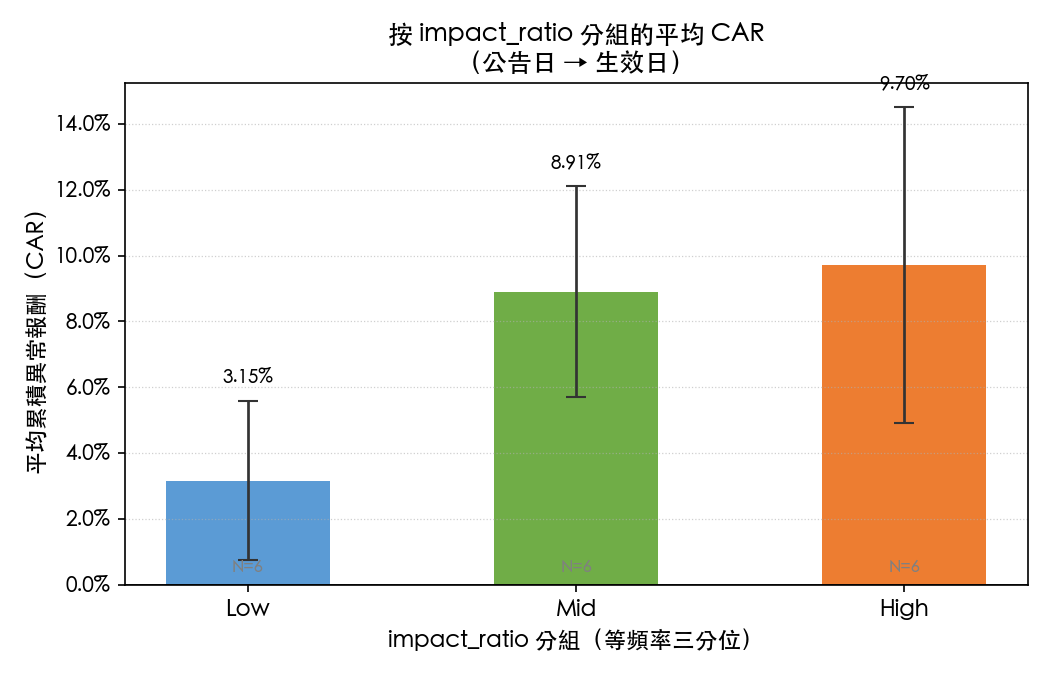


group_car_by_market_cap.png


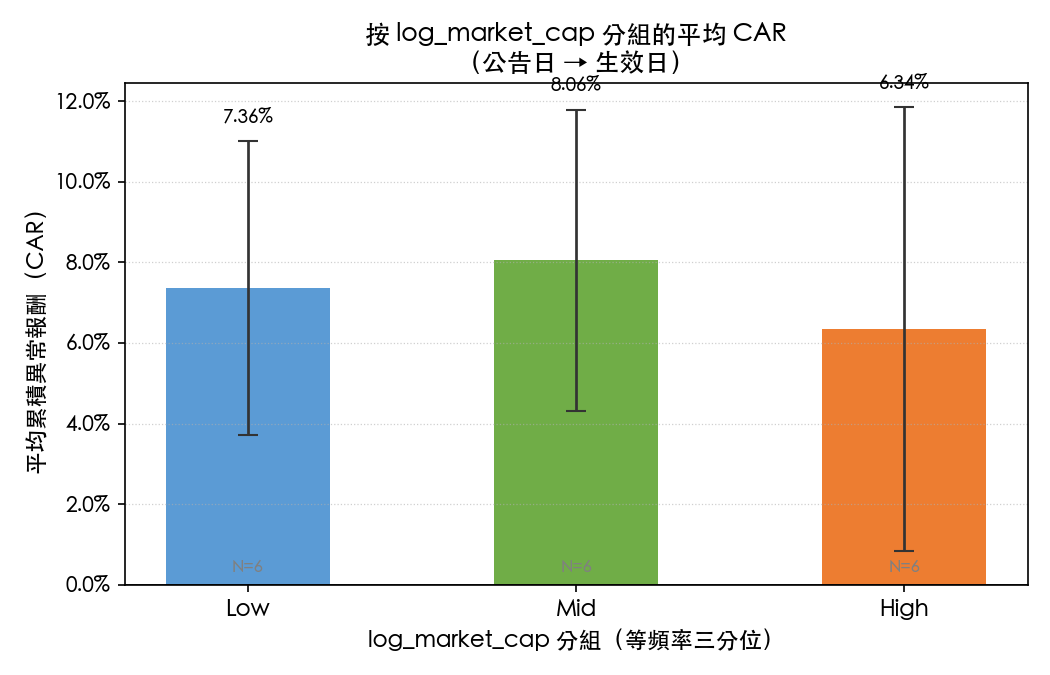


✅ Regression table: /Users/liuyenzhen/.claude/worktrees/nervous-cohen-8003bf/output/tables/regression_results.txt


In [12]:
from IPython.display import Image, display
import pathlib

for fig_path in [
    "../output/figures/group_car_by_impact.png",
    "../output/figures/group_car_by_market_cap.png",
]:
    p = pathlib.Path(fig_path)
    if p.exists():
        print(f"\n{p.name}")
        display(Image(p))

reg_path = pathlib.Path("../output/tables/regression_results.txt")
if reg_path.exists():
    print(f"\n✅ Regression table: {reg_path.resolve()}")